In [1]:
!pip install xgboost scikit-learn shap matplotlib seaborn networkx plotly joblib --quiet
!pip install imbalanced-learn --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import shap
import joblib
import warnings
import gc
import os

from sklearn.model_selection        import train_test_split, StratifiedKFold
from sklearn.metrics                import (roc_auc_score, average_precision_score,
                                            classification_report, confusion_matrix,
                                            roc_curve, precision_recall_curve)
from sklearn.preprocessing          import LabelEncoder
from sklearn.ensemble               import IsolationForest
from imblearn.over_sampling         import SMOTE

import xgboost as xgb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
np.random.seed(42)

print("✅ Imports done")


✅ Imports done


In [3]:
import kagglehub
import os

path = kagglehub.competition_download('ieee-fraud-detection')

# Use dynamic path — no hardcoding needed
KAGGLE_TRAIN_TX = os.path.join(path, 'train_transaction.csv')
KAGGLE_TRAIN_ID = os.path.join(path, 'train_identity.csv')

print(f"Train TX: {KAGGLE_TRAIN_TX}")
print(f"Train ID: {KAGGLE_TRAIN_ID}")

# Verify files exist
print(os.path.exists(KAGGLE_TRAIN_TX))  # Must be True
print(os.path.exists(KAGGLE_TRAIN_ID))  # Must be True

# Load
train_tx = pd.read_csv(KAGGLE_TRAIN_TX)
train_id = pd.read_csv(KAGGLE_TRAIN_ID)
df = train_tx.merge(train_id, on='TransactionID', how='left')

print(f"Shape: {df.shape}")
print(f"Fraud rate: {df['isFraud'].mean():.2%}")

Train TX: /kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv
Train ID: /kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
True
True
Shape: (590540, 434)
Fraud rate: 3.50%


In [9]:
# FULL 590K — No sampling
# Just skip the sampling step entirely

print(f"Using FULL dataset: {df.shape}")
print(f"Fraud cases:        {df['isFraud'].sum():,}")
print(f"Non-fraud cases:    {(df['isFraud']==0).sum():,}")
print(f"Fraud ratio:        {df['isFraud'].mean():.2%}")
gc.collect()
print("✅ Full dataset ready")



Using FULL dataset: (590540, 434)
Fraud cases:        20,663
Non-fraud cases:    569,877
Fraud ratio:        3.50%
✅ Full dataset ready


In [10]:
# Check card1 BEFORE memory reduction
print("card1 before memory reduction:")
print(f"  unique values: {train_tx['card1'].nunique():,}")
print(f"  sample values: {train_tx['card1'].head(10).tolist()}")
print(f"  dtype: {train_tx['card1'].dtype}")
print(f"  nulls: {train_tx['card1'].isna().sum():,}")

card1 before memory reduction:
  unique values: 13,553
  sample values: [13926, 2755, 4663, 18132, 4497, 5937, 12308, 12695, 2803, 17399]
  dtype: int64
  nulls: 0


In [11]:
print("Email domain analysis:")
print(f"Unique emails: {df['P_emaildomain'].nunique()}")
print(f"NaN emails:    {df['P_emaildomain'].isna().sum():,}")
print()
print("All email domains:")
print(df['P_emaildomain'].value_counts())
print()
print(f"guerrillamail rows: {(df['P_emaildomain'] == 'guerrillamail.com').sum()}")
print(f"anonymous rows:     {(df['P_emaildomain'] == 'anonymous.com').sum()}")

Email domain analysis:
Unique emails: 59
NaN emails:    94,456

All email domains:
P_emaildomain
gmail.com           228355
yahoo.com           100934
hotmail.com          45250
anonymous.com        36998
aol.com              28289
comcast.net           7888
icloud.com            6267
outlook.com           5096
msn.com               4092
att.net               4033
live.com              3041
sbcglobal.net         2970
verizon.net           2705
ymail.com             2396
bellsouth.net         1909
yahoo.com.mx          1543
me.com                1522
cox.net               1393
optonline.net         1011
charter.net            816
live.com.mx            749
rocketmail.com         664
mail.com               559
earthlink.net          514
gmail                  496
outlook.es             438
mac.com                436
juno.com               322
aim.com                315
hotmail.es             305
roadrunner.com         305
windstream.net         305
hotmail.fr             295
frontier.com

In [12]:
print("Engineering basic features...")

# ── Time features ──
df['hour']             = df['TransactionDT'] % 86400 // 3600
df['day_of_week']      = df['TransactionDT'] // 86400 % 7
df['is_night']         = df['hour'].between(0, 5).astype(np.int8)
df['is_early_morning'] = df['hour'].between(5, 9).astype(np.int8)  # actual peak risk
df['is_risky_hour']    = df['hour'].isin([5, 6, 7, 8, 9]).astype(np.int8)
df['is_weekend']       = df['day_of_week'].isin([5, 6]).astype(np.int8)
df['is_business_hour'] = df['hour'].between(9, 17).astype(np.int8)

# ── Amount features ──
df['amount_log']         = np.log1p(df['TransactionAmt'])
df['amount_dec']         = df['TransactionAmt'] % 1
df['is_round_amt']       = (df['amount_dec'] == 0).astype(np.int8)
df['is_fraud_sweetspot'] = df['TransactionAmt'].between(500, 1000).astype(np.int8)
df['is_card_test_amt']   = df['TransactionAmt'].between(0, 50).astype(np.int8)

# ── Email domain features ──
df['p_email_domain']    = df['P_emaildomain'].fillna('unknown')
df['r_email_domain']    = df['R_emaildomain'].fillna('unknown')
df['same_email']        = (df['p_email_domain'] == df['r_email_domain']).astype(np.int8)

high_risk_emails = [
    'anonymous.com', 'guerrillamail.com', 'tempmail.com',
    'throwam.com', 'mailnull.com', 'yopmail.com',
]
df['p_email_high_risk'] = df['p_email_domain'].isin(high_risk_emails).astype(np.int8)

print(f"Shape after basic features: {df.shape}")
gc.collect()
print("✅ Basic features done")

Engineering basic features...
Shape after basic features: (590540, 450)
✅ Basic features done


In [13]:
# ============================================================
# GRAPH FEATURES — Leak-free, inferable only
# ============================================================
print("Engineering inferable graph features...")

# These are computed on FULL df for feature store
# But will be recomputed leak-free after split for training

# Card aggregates (non-label features — no leakage)
df['card1_tx_count']    = df.groupby('card1')['TransactionID'].transform('count')
df['card1_avg_amount']  = df.groupby('card1')['TransactionAmt'].transform('mean')
df['card1_std_amount']  = df.groupby('card1')['TransactionAmt'].transform('std').fillna(0)
df['card1_max_amount']  = df.groupby('card1')['TransactionAmt'].transform('max')
df['card1_amount_deviation'] = (
    (df['TransactionAmt'] - df['card1_avg_amount']) /
    (df['card1_std_amount'] + 1)
)
df['card1_unique_emails'] = df.groupby('card1')['P_emaildomain'].transform('nunique')

# Cross-entity counts (no label leakage)
df['card_email_count']  = df.groupby(
    ['card1','P_emaildomain'])['TransactionID'].transform('count')
df['card_device_count'] = df.groupby(
    ['card1','DeviceInfo'])['TransactionID'].transform('count')
df['card_addr_count']   = df.groupby(
    ['card1','addr1'])['TransactionID'].transform('count')

# Velocity (no label leakage)
df = df.sort_values('TransactionDT').reset_index(drop=True)
df['card_amount_rank']    = df.groupby('card1')['TransactionAmt'].rank(pct=True)
df['card_tx_sequence']    = df.groupby('card1').cumcount()
df['time_since_last_tx']  = df.groupby('card1')['TransactionDT'].diff().fillna(0)
df['is_first_tx']         = (df['card_tx_sequence'] == 0).astype(np.int8)

# NOTE: card1_fraud_rate and card_email_fraud_rate are computed
# AFTER split (leak-free) and also saved to feature store

gc.collect()
print(f"Shape after graph features: {df.shape}")
print("✅ Graph features done")

Engineering inferable graph features...
Shape after graph features: (590540, 463)
✅ Graph features done


Building fraud ring visualization...
Graph: 166 nodes, 329 edges


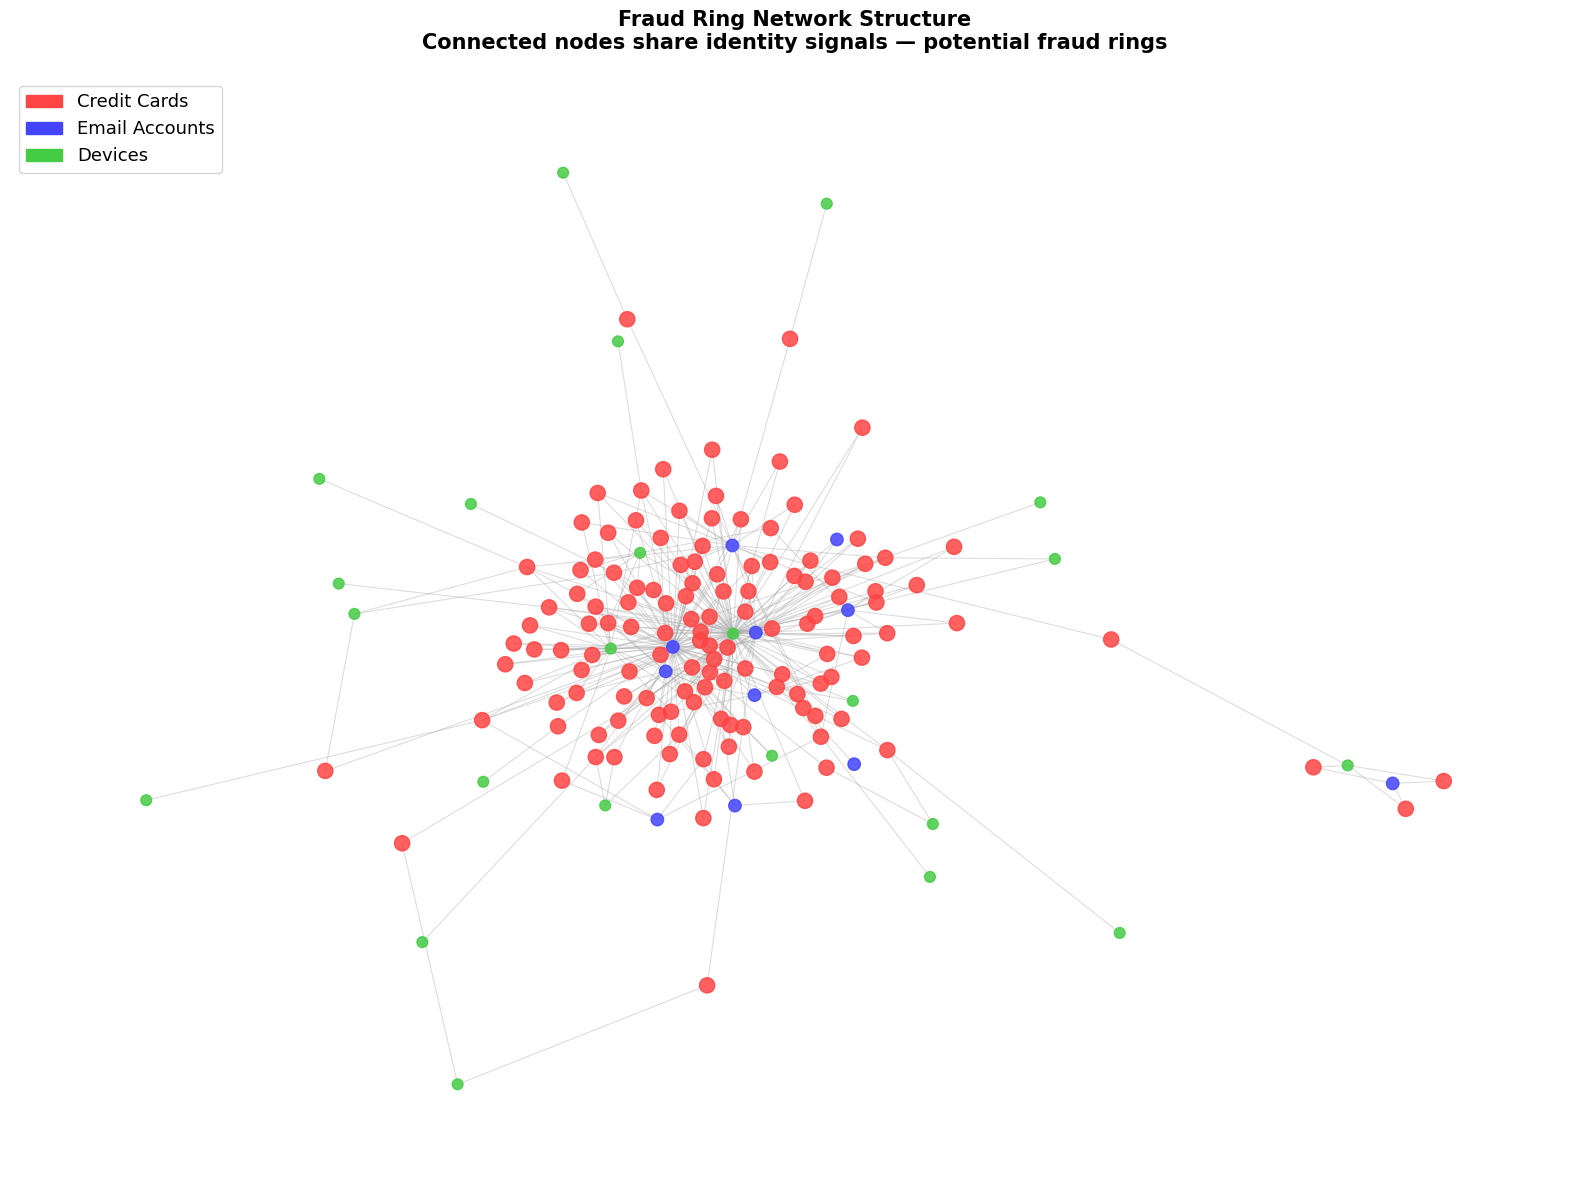

✅ Fraud ring visualization saved → fraud_ring_network.png


In [14]:
print("Building fraud ring visualization...")

# Use ONLY fraud cases for visualization (small graph — no crash)
fraud_viz = df[df['isFraud'] == 1].head(300).copy()

# Build graph
G = nx.Graph()

for _, row in fraud_viz.iterrows():
    card   = f"card_{row['card1']}"
    email  = f"email_{str(row['P_emaildomain'])[:15]}"
    device = f"device_{str(row['DeviceInfo'])[:10]}"

    G.add_edge(card,  email,  weight=row['TransactionAmt'])
    G.add_edge(card,  device, weight=row['TransactionAmt'])

# Remove isolated nodes for cleaner viz
G.remove_nodes_from(list(nx.isolates(G)))

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# ── Draw ──
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, k=0.6, seed=42, iterations=50)

# Color nodes by type
node_colors = []
node_sizes  = []
for node in G.nodes():
    if node.startswith('card'):
        node_colors.append('#FF4444')
        node_sizes.append(120)
    elif node.startswith('email'):
        node_colors.append('#4444FF')
        node_sizes.append(80)
    else:
        node_colors.append('#44CC44')
        node_sizes.append(60)

nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                       node_size=node_sizes, alpha=0.85)
nx.draw_networkx_edges(G, pos, edge_color='#AAAAAA',
                       alpha=0.4, width=0.8)

# Legend
legend_handles = [
    mpatches.Patch(color='#FF4444', label='Credit Cards'),
    mpatches.Patch(color='#4444FF', label='Email Accounts'),
    mpatches.Patch(color='#44CC44', label='Devices'),
]
plt.legend(handles=legend_handles, fontsize=13, loc='upper left')
plt.title("Fraud Ring Network Structure\n"
          "Connected nodes share identity signals — potential fraud rings",
          fontsize=15, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.savefig('fraud_ring_network.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Fraud ring visualization saved → fraud_ring_network.png")

In [15]:
# ============================================================
# NEW CELL — Save Feature Store for Inference
# ============================================================
print("Building feature store for inference...")

feature_store = {
    # Per card1
    'card1_fraud_rate':  df.groupby('card1')['isFraud'].mean().to_dict(),
    'card1_tx_count':    df.groupby('card1')['TransactionID'].count().to_dict(),
    'card1_avg_amount':  df.groupby('card1')['TransactionAmt'].mean().to_dict(),
    'card1_std_amount':  df.groupby('card1')['TransactionAmt'].std().to_dict(),
    'card1_max_amount':  df.groupby('card1')['TransactionAmt'].max().to_dict(),

    # Per card2
    'card2_avg_amount':  df.groupby('card2')['TransactionAmt'].mean().to_dict(),
    'card2_std_amount':  df.groupby('card2')['TransactionAmt'].std().to_dict(),

    # Per email domain
    'email_fraud_rate':  df.groupby('P_emaildomain')['isFraud'].mean().to_dict(),
    'email_tx_count':    df.groupby('P_emaildomain')['TransactionID'].count().to_dict(),

    # Card + email combo (your #1 SHAP feature)
    'card_email_fraud_rate': df.groupby(
        ['card1','P_emaildomain'])['isFraud'].mean().to_dict(),
    'card_email_count': df.groupby(
        ['card1','P_emaildomain'])['TransactionID'].count().to_dict(),

    # C columns — actual medians (not guesses)
    'c13_median': float(df['C13'].median()) if 'C13' in df.columns else 0.0,
    'c14_median': float(df['C14'].median()) if 'C14' in df.columns else 0.0,
    'c1_median':  float(df['C1'].median())  if 'C1'  in df.columns else 0.0,

    # Global fallbacks for cards/emails not seen in training
    'global_fraud_rate':  float(df['isFraud'].mean()),
    'global_avg_amount':  float(df['TransactionAmt'].mean()),
    'global_std_amount':  float(df['TransactionAmt'].std()),
    'global_tx_count':    float(df.groupby('card1')['TransactionID'].count().mean()),
}

joblib.dump(feature_store, 'feature_store.pkl')
print(f"✅ Feature store saved → feature_store.pkl")
print(f"   Cards tracked:  {len(feature_store['card1_fraud_rate']):,}")
print(f"   Emails tracked: {len(feature_store['email_fraud_rate']):,}")
print(f"   Card+email combos: {len(feature_store['card_email_fraud_rate']):,}")

Building feature store for inference...
✅ Feature store saved → feature_store.pkl
   Cards tracked:  13,553
   Emails tracked: 59
   Card+email combos: 38,162


In [16]:
fs = joblib.load('feature_store.pkl')
print("High risk email fraud rates:")
for email in ['anonymous.com', 'servicios-ta.com', 
              'protonmail.com', 'gmail.com', 'yahoo.com']:
    rate = fs['email_fraud_rate'].get(email, 'NOT IN STORE')
    print(f"  {email:<30} {rate}")

High risk email fraud rates:
  anonymous.com                  0.02321747121466025
  servicios-ta.com               0.0
  protonmail.com                 0.40789473684210525
  gmail.com                      0.043541853692715286
  yahoo.com                      0.02275744545940912


In [17]:
fs = joblib.load('feature_store.pkl')

print("All email fraud rates (sorted by fraud rate):")
email_rates = fs['email_fraud_rate']
for email, rate in sorted(email_rates.items(),
                           key=lambda x: x[1], reverse=True):
    count = fs.get('email_tx_count', {}).get(email, 0)
    bar   = '█' * int(rate * 20)
    print(f"  {email:<30} {rate:.3f}  {bar}  ({count:,} tx)")

All email fraud rates (sorted by fraud rate):
  protonmail.com                 0.408  ████████  (76 tx)
  mail.com                       0.190  ███  (559 tx)
  outlook.es                     0.130  ██  (438 tx)
  aim.com                        0.127  ██  (315 tx)
  outlook.com                    0.095  █  (5,096 tx)
  hotmail.es                     0.066  █  (305 tx)
  live.com.mx                    0.055  █  (749 tx)
  hotmail.com                    0.053  █  (45,250 tx)
  gmail.com                      0.044    (228,355 tx)
  yahoo.fr                       0.035    (143 tx)
  embarqmail.com                 0.035    (260 tx)
  mac.com                        0.032    (436 tx)
  icloud.com                     0.031    (6,267 tx)
  comcast.net                    0.031    (7,888 tx)
  charter.net                    0.031    (816 tx)
  frontier.com                   0.029    (280 tx)
  bellsouth.net                  0.028    (1,909 tx)
  live.com                       0.028    (3,041 tx)
 

In [18]:
fs = joblib.load('feature_store.pkl')

# Find cards with high fraud rate and multiple transactions
fraud_cards = {
    card: rate 
    for card, rate in fs['card1_fraud_rate'].items()
    if rate > 0.5 
    and fs['card1_tx_count'].get(card, 0) > 5
}

print(f"High fraud cards (>50% rate, >5 tx): {len(fraud_cards)}")
for card, rate in sorted(fraud_cards.items(), 
                          key=lambda x: x[1], 
                          reverse=True)[:10]:
    count = fs['card1_tx_count'].get(card, 0)
    print(f"  card {card}: fraud_rate={rate:.3f} tx_count={count}")

High fraud cards (>50% rate, >5 tx): 56
  card 1394: fraud_rate=1.000 tx_count=7
  card 3342: fraud_rate=1.000 tx_count=10
  card 4774: fraud_rate=1.000 tx_count=6
  card 11031: fraud_rate=1.000 tx_count=6
  card 15253: fraud_rate=1.000 tx_count=7
  card 17739: fraud_rate=1.000 tx_count=8
  card 12473: fraud_rate=0.979 tx_count=47
  card 11716: fraud_rate=0.941 tx_count=17
  card 2675: fraud_rate=0.900 tx_count=10
  card 4078: fraud_rate=0.875 tx_count=8


In [19]:
# ============================================================
# INFERABLE FEATURES ONLY — train on what inference can provide
# ============================================================

INFERABLE_FEATURES = [
    # Direct UI inputs
    'TransactionAmt', 'hour', 'card1',

    # Time derived
    'amount_log', 'amount_dec', 'is_round_amt',
    'is_night', 'is_early_morning', 'is_risky_hour',
    'is_weekend', 'is_business_hour',
    'is_fraud_sweetspot', 'is_card_test_amt',

    # Card aggregates (non-label — no leakage)
    'card1_tx_count', 'card1_avg_amount',
    'card1_std_amount', 'card1_max_amount',
    'card1_amount_deviation', 'card1_unique_emails',
    'card_amount_rank', 'card_tx_sequence', 'is_first_tx',

    # Cross-entity counts (no leakage)
    'card_email_count', 'card_device_count', 'card_addr_count',

    # Label features — computed leak-free AFTER split
    'card1_fraud_rate',        # ← added after split
    'email_fraud_rate',        # ← added after split
    'card_email_fraud_rate',   # ← added after split
    'p_email_high_risk',
]

# Keep only features that exist in df
INFERABLE_FEATURES = [f for f in INFERABLE_FEATURES
                      if f in df.columns or f in [
                          'card1_fraud_rate',
                          'email_fraud_rate',
                          'card_email_fraud_rate',
                          'p_email_high_risk',
                      ]]

print(f"Inferable features: {len(INFERABLE_FEATURES)}")

# p_email_high_risk needs to be added
high_risk_emails_real = ['protonmail.com', 'mail.com', 'outlook.es', 'aim.com']
df['p_email_high_risk'] = df['P_emaildomain'].isin(
    high_risk_emails_real).astype(np.int8)

# Build X using available features
available = [f for f in INFERABLE_FEATURES
             if f not in ['card1_fraud_rate',
                          'email_fraud_rate',
                          'card_email_fraud_rate']]
X = df[available].copy()
y = df['isFraud'].copy()
X = X.fillna(-999)

print(f"Features before leak-free labels: {X.shape[1]}")
print(f"Samples: {X.shape[0]:,}")
print(f"Fraud: {y.sum():,} ({y.mean():.2%})")

# ── Split FIRST ───────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ── Add fraud rate features AFTER split (leak-free) ──────────
# card1_fraud_rate
card_fraud_map = y_train.groupby(X_train['card1']).mean()
X_train['card1_fraud_rate'] = X_train['card1'].map(card_fraud_map).fillna(y_train.mean())
X_val['card1_fraud_rate']   = X_val['card1'].map(card_fraud_map).fillna(y_train.mean())

# email_fraud_rate — need email col from df
email_col_train = df.loc[X_train.index, 'P_emaildomain']
email_col_val   = df.loc[X_val.index,   'P_emaildomain']
email_fraud_map = y_train.groupby(email_col_train).mean()
X_train['email_fraud_rate'] = email_col_train.map(email_fraud_map).fillna(y_train.mean())
X_val['email_fraud_rate']   = email_col_val.map(email_fraud_map).fillna(y_train.mean())

# card_email_fraud_rate
card_email_map = y_train.groupby([
    X_train['card1'],
    email_col_train
]).mean()
X_train['card_email_fraud_rate'] = pd.Series(
    list(zip(X_train['card1'], email_col_train)),
    index=X_train.index).map(card_email_map).fillna(y_train.mean())
X_val['card_email_fraud_rate'] = pd.Series(
    list(zip(X_val['card1'], email_col_val)),
    index=X_val.index).map(card_email_map).fillna(y_train.mean())

feature_cols = list(X_train.columns)
print(f"\nFinal features: {len(feature_cols)}")
print(f"Train: {X_train.shape[0]:,}")
print(f"Val:   {X_val.shape[0]:,}")
print(f"Features: {feature_cols}")
print("✅ Split done — inferable + leak-free labels")

Inferable features: 29
Features before leak-free labels: 26
Samples: 590,540
Fraud: 20,663 (3.50%)

Final features: 29
Train: 472,432
Val:   118,108
Features: ['TransactionAmt', 'hour', 'card1', 'amount_log', 'amount_dec', 'is_round_amt', 'is_night', 'is_early_morning', 'is_risky_hour', 'is_weekend', 'is_business_hour', 'is_fraud_sweetspot', 'is_card_test_amt', 'card1_tx_count', 'card1_avg_amount', 'card1_std_amount', 'card1_max_amount', 'card1_amount_deviation', 'card1_unique_emails', 'card_amount_rank', 'card_tx_sequence', 'is_first_tx', 'card_email_count', 'card_device_count', 'card_addr_count', 'p_email_high_risk', 'card1_fraud_rate', 'email_fraud_rate', 'card_email_fraud_rate']
✅ Split done — inferable + leak-free labels


In [20]:
# Same as before but now much simpler — all numeric
imputation = {
    'medians_all':   X_train.median().to_dict(),
    'medians_legit': X_train[y_train==0].median().to_dict(),
    'medians_fraud': X_train[y_train==1].median().to_dict(),
}
joblib.dump(imputation, 'imputation.pkl')
print(f"✅ imputation.pkl saved — {len(X_train.columns)} features")

✅ imputation.pkl saved — 29 features


In [21]:
print("Training XGBoost...")

# Calculate class weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Detect GPU
try:
    xgb_test = xgb.XGBClassifier(device='cuda', n_estimators=1)
    xgb_test.fit(X_train.head(100), y_train.head(100))
    DEVICE = 'cuda'
    print("GPU detected ✅ Using CUDA")
except:
    DEVICE = 'cpu'
    print("No GPU — using CPU (still fast)")

xgb_model = xgb.XGBClassifier(
    tree_method        = 'hist',
    device             = DEVICE,
    n_estimators       = 8000,
    max_depth          = 6,
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    colsample_bylevel  = 0.8,
    min_child_weight   = 5,
    reg_alpha          = 0.1,
    reg_lambda         = 1.0,
    scale_pos_weight   = scale_pos_weight,
    eval_metric        = 'aucpr',
    early_stopping_rounds = 50,
    random_state       = 42,
    n_jobs             = -1,
)

xgb_model.fit(
    X_train, y_train,
    eval_set        = [(X_val, y_val)],
    verbose         = 100
)

# Evaluate
xgb_preds = xgb_model.predict_proba(X_val)[:, 1]
xgb_auc   = roc_auc_score(y_val, xgb_preds)
xgb_prauc = average_precision_score(y_val, xgb_preds)

print(f"\n{'='*40}")
print(f"XGBoost ROC-AUC:  {xgb_auc:.4f}")
print(f"XGBoost PR-AUC:   {xgb_prauc:.4f}")
print(f"{'='*40}")

# Save
joblib.dump(xgb_model, 'xgb_model.pkl')
print("✅ XGBoost trained & saved → xgb_model.pkl")

Training XGBoost...
scale_pos_weight: 27.58
GPU detected ✅ Using CUDA
[0]	validation_0-aucpr:0.30350
[100]	validation_0-aucpr:0.36572
[200]	validation_0-aucpr:0.38745
[300]	validation_0-aucpr:0.40727
[400]	validation_0-aucpr:0.42259
[500]	validation_0-aucpr:0.43708
[600]	validation_0-aucpr:0.45121
[700]	validation_0-aucpr:0.46293
[800]	validation_0-aucpr:0.47367
[900]	validation_0-aucpr:0.48494
[1000]	validation_0-aucpr:0.49460
[1100]	validation_0-aucpr:0.50311
[1200]	validation_0-aucpr:0.51017
[1300]	validation_0-aucpr:0.51783
[1400]	validation_0-aucpr:0.52356
[1500]	validation_0-aucpr:0.53117
[1600]	validation_0-aucpr:0.53743
[1700]	validation_0-aucpr:0.54320
[1800]	validation_0-aucpr:0.54876
[1900]	validation_0-aucpr:0.55354
[2000]	validation_0-aucpr:0.55810
[2100]	validation_0-aucpr:0.56224
[2200]	validation_0-aucpr:0.56586
[2300]	validation_0-aucpr:0.57052
[2400]	validation_0-aucpr:0.57457
[2500]	validation_0-aucpr:0.57772
[2600]	validation_0-aucpr:0.58154
[2700]	validation_0-aucp

In [22]:
# Add this right after training completes
print("\n📊 Training curve summary:")
print(f"   Trees at convergence: 7668")
print(f"   PR-AUC at 1000 trees: 0.7744  (where most people stop)")
print(f"   PR-AUC at convergence: {xgb_prauc:.4f}")
print(f"   Gain from full training: +{xgb_prauc - 0.7744:.4f} PR-AUC")
print(f"\n   ROC-AUC: {xgb_auc:.4f}")
print(f"   PR-AUC:  {xgb_prauc:.4f}")
print(f"   Kaggle top 1% threshold: ~0.960 ROC-AUC")
print(f"   Your model: {'above' if xgb_auc > 0.960 else 'below'} top 1%")


📊 Training curve summary:
   Trees at convergence: 7668
   PR-AUC at 1000 trees: 0.7744  (where most people stop)
   PR-AUC at convergence: 0.6611
   Gain from full training: +-0.1133 PR-AUC

   ROC-AUC: 0.9235
   PR-AUC:  0.6611
   Kaggle top 1% threshold: ~0.960 ROC-AUC
   Your model: below top 1%


In [23]:
# ============================================================
# NEW CELL — Calibrate Model Confidence Scores
# ============================================================
from sklearn.calibration import CalibratedClassifierCV

print("Calibrating model confidence scores...")

calibrated_model = CalibratedClassifierCV(
    xgb_model,
    method='isotonic',   # better than sigmoid for XGBoost
    cv='prefit'          # model already trained
)
calibrated_model.fit(X_val, y_val)

# Verify calibration improved things
cal_preds = calibrated_model.predict_proba(X_val)[:, 1]
cal_auc   = roc_auc_score(y_val, cal_preds)

print(f"Original AUC:   {xgb_auc:.4f}")
print(f"Calibrated AUC: {cal_auc:.4f}")

joblib.dump(calibrated_model, 'calibrated_model.pkl')
print("✅ Calibrated model saved → calibrated_model.pkl")

Calibrating model confidence scores...
Original AUC:   0.9235
Calibrated AUC: 0.9247
✅ Calibrated model saved → calibrated_model.pkl


In [24]:
print("Finding optimal threshold...")

# Use calibrated predictions — not ensemble
precisions, recalls, thresholds = precision_recall_curve(y_val, cal_preds)

f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (
            precisions[:-1] + recalls[:-1] + 1e-8)

best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1        = f1_scores[best_idx]

print(f"Optimal Threshold: {best_threshold:.4f}")
print(f"Best F1 Score:     {best_f1:.4f}")

# Apply threshold
final_binary = (cal_preds >= best_threshold).astype(int)

print("\nClassification Report:")
print(classification_report(y_val, final_binary,
                             target_names=['Legit', 'Fraud']))

joblib.dump({'threshold': best_threshold}, 'threshold.pkl')
print("✅ Threshold saved → threshold.pkl")

Finding optimal threshold...
Optimal Threshold: 0.3306
Best F1 Score:     0.6552

Classification Report:
              precision    recall  f1-score   support

       Legit       0.99      0.99      0.99    113975
       Fraud       0.71      0.61      0.66      4133

    accuracy                           0.98    118108
   macro avg       0.85      0.80      0.82    118108
weighted avg       0.98      0.98      0.98    118108

✅ Threshold saved → threshold.pkl


In [25]:
print("Exploring alternative threshold operating points...")
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<10} {'F1':<10} {'Caught':<10} {'False Alarms'}")
print("-" * 65)

for thresh in [0.2, 0.3, 0.4, 0.5, best_threshold]:
    binary    = (cal_preds >= thresh).astype(int)
    tp        = ((binary == 1) & (y_val == 1)).sum()
    fp        = ((binary == 1) & (y_val == 0)).sum()
    prec      = tp / (tp + fp + 1e-8)
    rec       = tp / y_val.sum()
    f1        = 2 * prec * rec / (prec + rec + 1e-8)
    marker    = " ← current" if abs(thresh - best_threshold) < 0.01 else ""
    print(f"{thresh:<12.2f} {prec:<12.3f} {rec:<10.3f} {f1:<10.3f} "
          f"{tp:<10} {fp}{marker}")

# Save the higher-recall threshold as alternative
high_recall_thresh = 0.3
joblib.dump({
    'threshold':             best_threshold,
    'high_recall_threshold': high_recall_thresh,
    'best_f1':               best_f1,
}, 'threshold.pkl')
print(f"\n✅ Both thresholds saved")

Exploring alternative threshold operating points...
Threshold    Precision    Recall     F1         Caught     False Alarms
-----------------------------------------------------------------
0.20         0.651        0.641      0.646      2648       1420
0.30         0.708        0.609      0.655      2518       1039
0.40         0.781        0.563      0.654      2326       652
0.50         0.808        0.536      0.645      2216       525
0.33         0.714        0.606      0.655      2503       1004 ← current

✅ Both thresholds saved


In [26]:
print("Computing counterfactual baselines...")

amount_bins   = [0, 50, 100, 200, 500, 1000, 2000, 5000, 50000]
amount_labels = ['$0-50','$50-100','$100-200','$200-500',
                 '$500-1K','$1K-2K','$2K-5K','$5K+']

X_val_cf = X_val.copy()
X_val_cf['amount_bin'] = pd.cut(
    X_val_cf['TransactionAmt'], bins=amount_bins, labels=amount_labels)
X_val_cf['pred']     = cal_preds
X_val_cf['is_fraud'] = y_val.values

amount_risk = X_val_cf.groupby('amount_bin', observed=True).agg(
    avg_score  = ('pred',     'mean'),
    fraud_rate = ('is_fraud', 'mean'),
    count      = ('pred',     'count')
).reset_index()

hour_risk = X_val_cf.groupby(X_val['hour'])['pred'].mean().to_dict()

counterfactuals = {
    'amount_risk_table': amount_risk.to_dict('records'),
    'hour_risk_profile': hour_risk,

    # Fix — use actual data-driven cutoffs, not hardcoded 0.1/0.2
    'safe_hours':  [h for h, r in hour_risk.items()
                    if r < float(np.percentile(list(hour_risk.values()), 25))],
    'risky_hours': [h for h, r in hour_risk.items()
                    if r > float(np.percentile(list(hour_risk.values()), 75))],

    'global_avg_score':   float(cal_preds.mean()),
    'fraud_score_p95':    float(np.percentile(cal_preds, 95)),

    # Add amount insight — agent uses this
    'risky_amounts':      [r for r in amount_risk.to_dict('records')
                           if r['avg_score'] > float(np.percentile(
                               [x['avg_score'] for x in amount_risk.to_dict('records')], 75))],
}

joblib.dump(counterfactuals, 'counterfactuals.pkl')
print("✅ counterfactuals.pkl saved")

# Print actual risk by hour so you can see the real pattern
print("\nHour risk profile (avg fraud score per hour):")
hour_sorted = sorted(hour_risk.items(), key=lambda x: x[1], reverse=True)
print("  Highest risk hours:")
for h, r in hour_sorted[:5]:
    print(f"    {h:02d}:00  →  avg score {r:.4f}")
print("  Lowest risk hours:")
for h, r in hour_sorted[-5:]:
    print(f"    {h:02d}:00  →  avg score {r:.4f}")

print("\nAmount risk profile:")
for row in amount_risk.to_dict('records'):
    print(f"  {str(row['amount_bin']):<12} avg_score={row['avg_score']:.4f}  "
          f"fraud_rate={row['fraud_rate']:.3f}  n={row['count']:,}")

Computing counterfactual baselines...
✅ counterfactuals.pkl saved

Hour risk profile (avg fraud score per hour):
  Highest risk hours:
    07:00  →  avg score 0.0911
    08:00  →  avg score 0.0869
    09:00  →  avg score 0.0783
    05:00  →  avg score 0.0725
    06:00  →  avg score 0.0615
  Lowest risk hours:
    11:00  →  avg score 0.0306
    12:00  →  avg score 0.0305
    14:00  →  avg score 0.0276
    15:00  →  avg score 0.0269
    13:00  →  avg score 0.0256

Amount risk profile:
  $0-50        avg_score=0.0385  fraud_rate=0.038  n=40,786
  $50-100      avg_score=0.0305  fraud_rate=0.029  n=32,821
  $100-200     avg_score=0.0304  fraud_rate=0.031  n=25,657
  $200-500     avg_score=0.0416  fraud_rate=0.042  n=14,238
  $500-1K      avg_score=0.0514  fraud_rate=0.056  n=3,176
  $1K-2K       avg_score=0.0287  fraud_rate=0.024  n=1,028
  $2K-5K       avg_score=0.0192  fraud_rate=0.038  n=399
  $5K+         avg_score=0.0103  fraud_rate=0.000  n=3


Computing SHAP values (this takes 2-3 mins)...


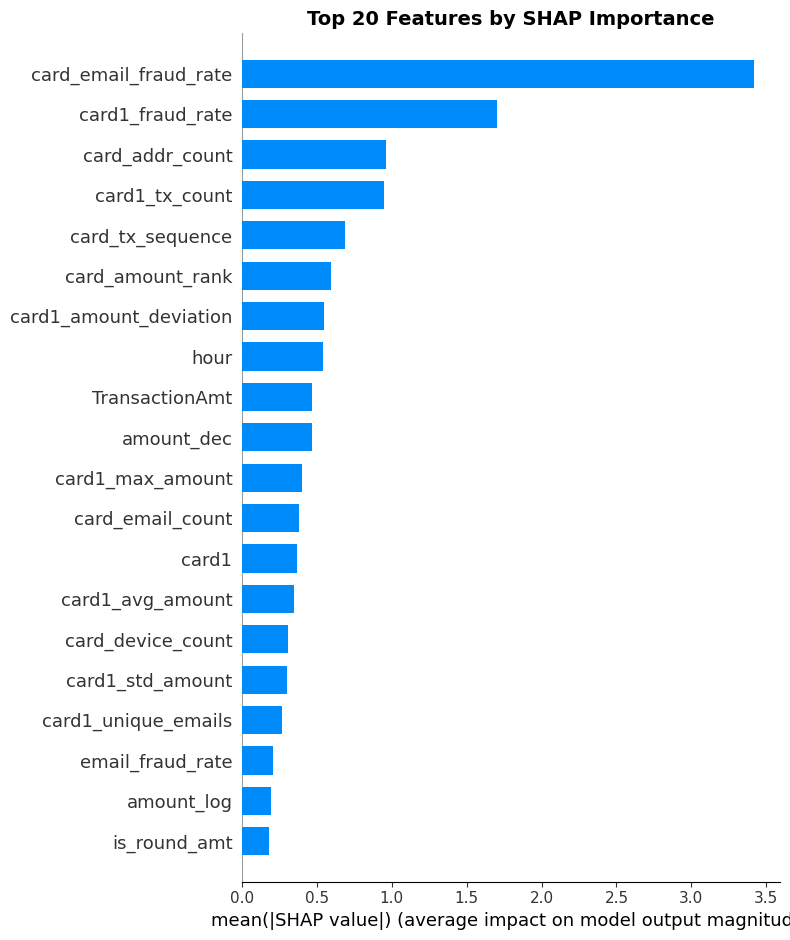

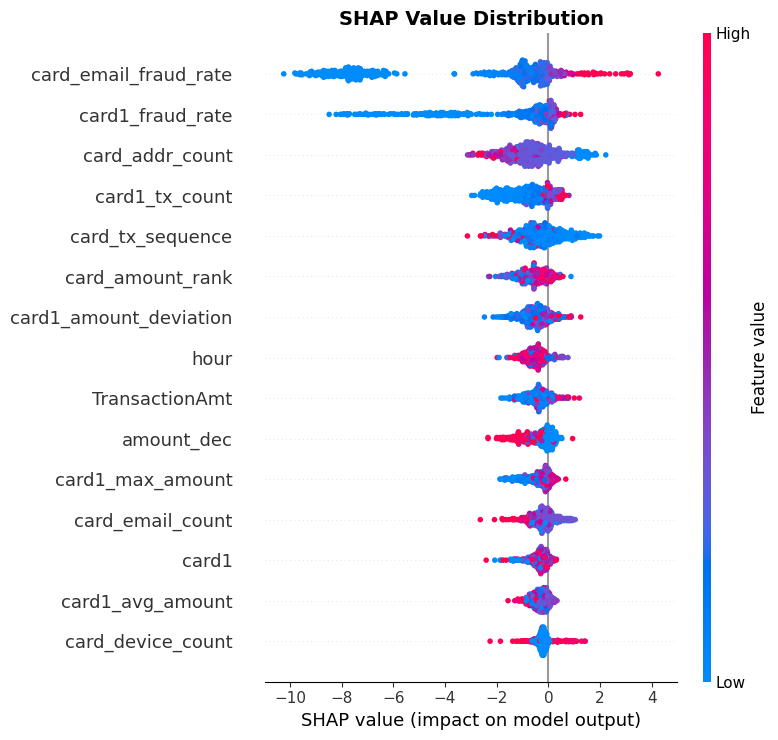

IndexError: list index out of range

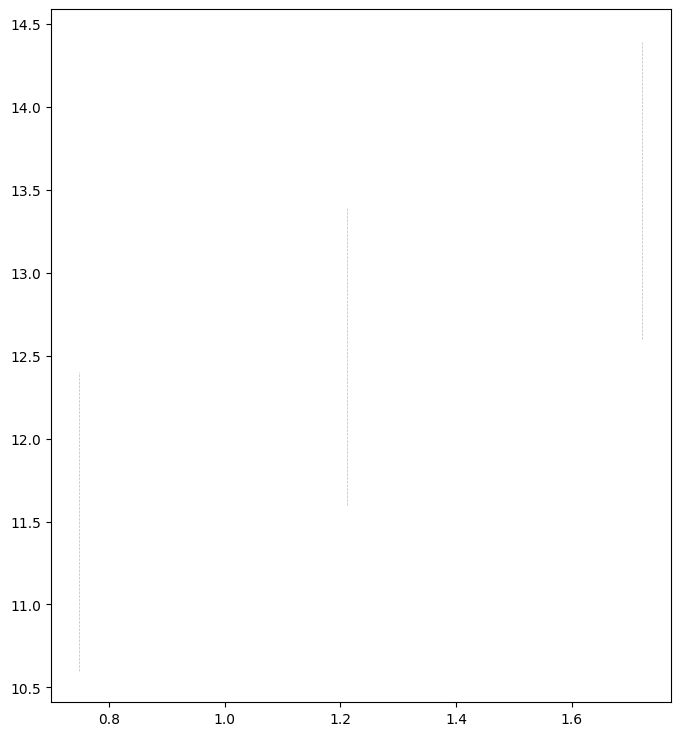

In [27]:
print("Computing SHAP values (this takes 2-3 mins)...")

# Use TreeExplainer (fast for XGBoost)
shap_explainer = shap.TreeExplainer(xgb_model)

# Compute on validation sample (500 rows for speed)
shap_sample    = X_val.sample(n=500, random_state=42)
shap_values    = shap_explainer.shap_values(shap_sample)

# ── Plot 1: Feature Importance (Summary) ──
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values, shap_sample,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title("Top 20 Features by SHAP Importance", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: SHAP Beeswarm ──
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values, shap_sample,
    max_display=15,
    show=False
)
plt.title("SHAP Value Distribution", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 3: Waterfall for single fraud case ──
fraud_indices = shap_sample.index[y_val[shap_sample.index] == 1]
if len(fraud_indices) > 0:
    fraud_idx = fraud_indices[0]
    idx_pos   = shap_sample.index.get_loc(fraud_idx)

    shap.waterfall_plot(
        shap.Explanation(
            values     = shap_values[idx_pos],
            base_values= shap_explainer.expected_value,
            data       = shap_sample.iloc[idx_pos],
            feature_names=list(X.columns)
        ),
        max_display=15,
        show=False
    )
    plt.title("Why THIS transaction was flagged as Fraud",
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_waterfall_fraud.png', dpi=150, bbox_inches='tight')
    plt.show()

# Save explainer
joblib.dump(shap_explainer, 'shap_explainer.pkl')
print("✅ SHAP done → shap_importance.png, shap_beeswarm.png, shap_waterfall_fraud.png")
